In [2]:
print("Hello World")

Hello World


# CODE ARCHITECTURE
Imports <br>
Load one joint CSV <br>
Timestamp conversion <br> 
Acceleration calculation <br>
Friction torque calculation <br>
Data visualization <br>
Prepare features <br>
Scaling <br>
Train/Test split <br>
PINN parameters <br>
Neural Network <br>
Training loop <br>
Parameter estimation <br>
Prediction <br>
Friction curve <br>

# IMPORT PACKAGES AND LIBRARIES

In [3]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


# IMPORT DATA FROM CSV FILES

In [4]:
folder_path = "S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data"

j1 = pd.read_csv(folder_path + r"\J_1_05.06.2026_14_46_55.csv")
j2 = pd.read_csv(folder_path + r"\J_2_05.06.2026_16_48_47.csv")
j3 = pd.read_csv(folder_path + r"\J_3_05.06.2026_14_43_16.csv")
j4 = pd.read_csv(folder_path + r"\J_4_05.06.2026_14_39_00.csv")
j5 = pd.read_csv(folder_path + r"\J_5_05.06.2026_14_29_39.csv")

print(j1.shape)
print(j2.shape)
print(j3.shape)
print(j4.shape)
print(j5.shape)

(49646, 25)
(24216, 25)
(12466, 25)
(42015, 25)
(34440, 25)


# PLOTTING THE TIMESTAMP VS MT JTS V Q

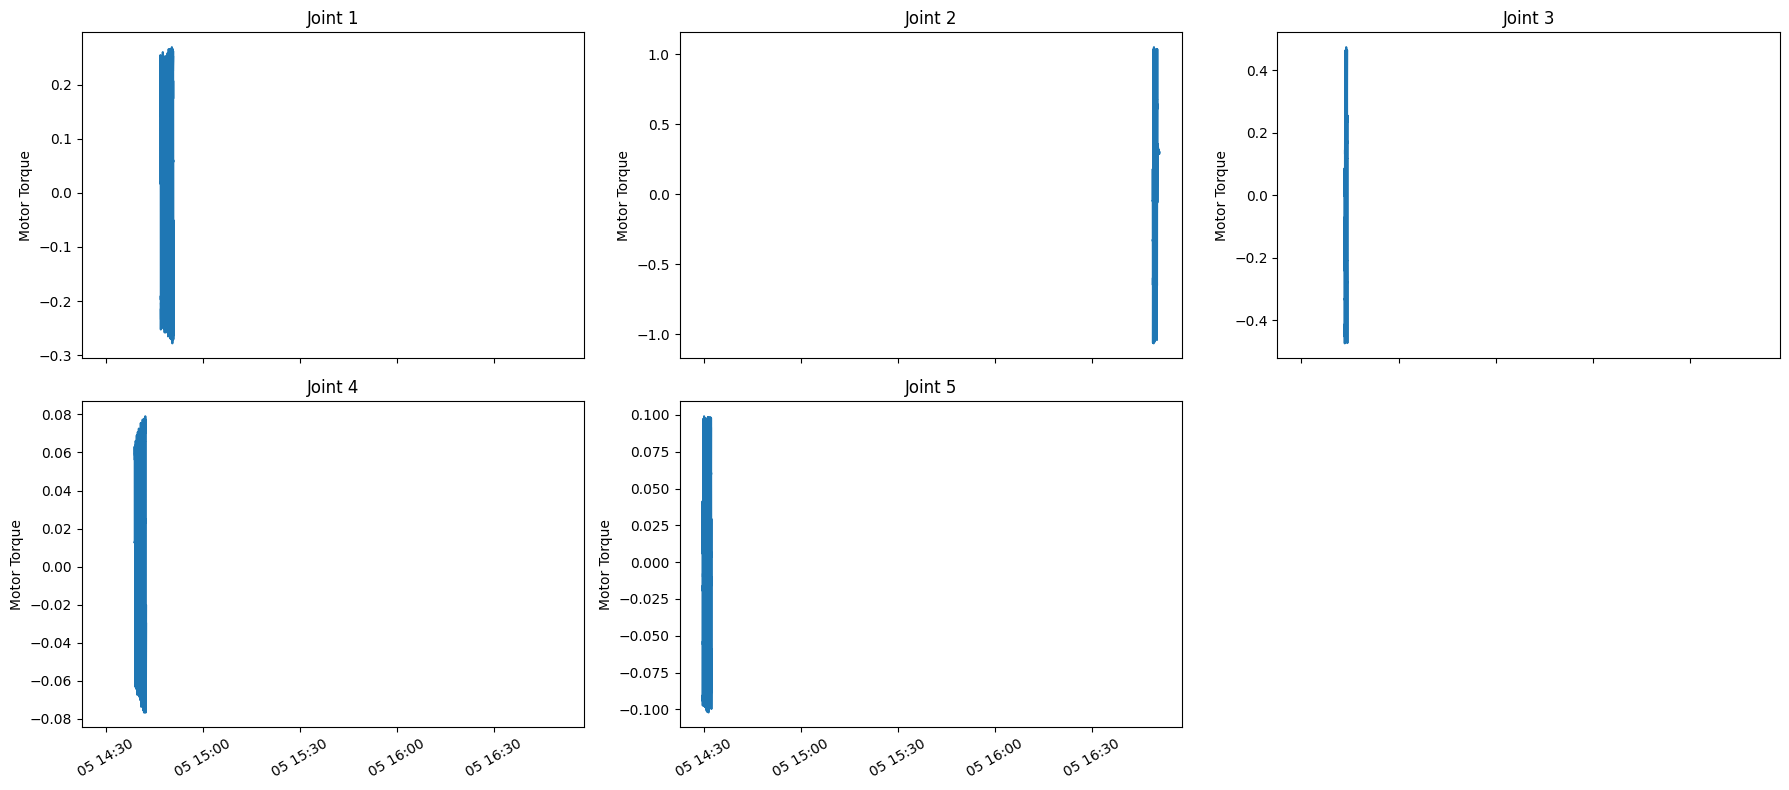

In [ ]:
for df in [j1, j2, j3, j4, j5]:
    df["timestamp"] = pd.to_datetime(
        "2026-06-05 " + df["timestamp"].astype(str)
    )

joint_files = [j1, j2, j3, j4, j5]
for joint_no, df in zip([1,2,3,4,5], joint_files):
    fig, axs = plt.subplots(
        4, 1,
        figsize=(15,12),
        sharex=True
    )

    axs[0].plot(
        df["timestamp"],
        df[f"m_t_{joint_no}"]
    )
    axs[0].set_ylabel("Motor Torque")
    axs[0].set_title(f"Joint {joint_no}")

    axs[1].plot(
        df["timestamp"],
        df[f"jts{joint_no}"]
    )
    axs[1].set_ylabel("Joint Torque")

    axs[2].plot(
        df["timestamp"],
        df[f"v{joint_no}"]
    )
    axs[2].set_ylabel("Velocity")

    axs[3].plot(
        df["timestamp"],
        df[f"q{joint_no}"]
    )
    axs[3].set_ylabel("Position")
    axs[3].set_xlabel("Timestamp")

    plt.tight_layout()
    plt.show()

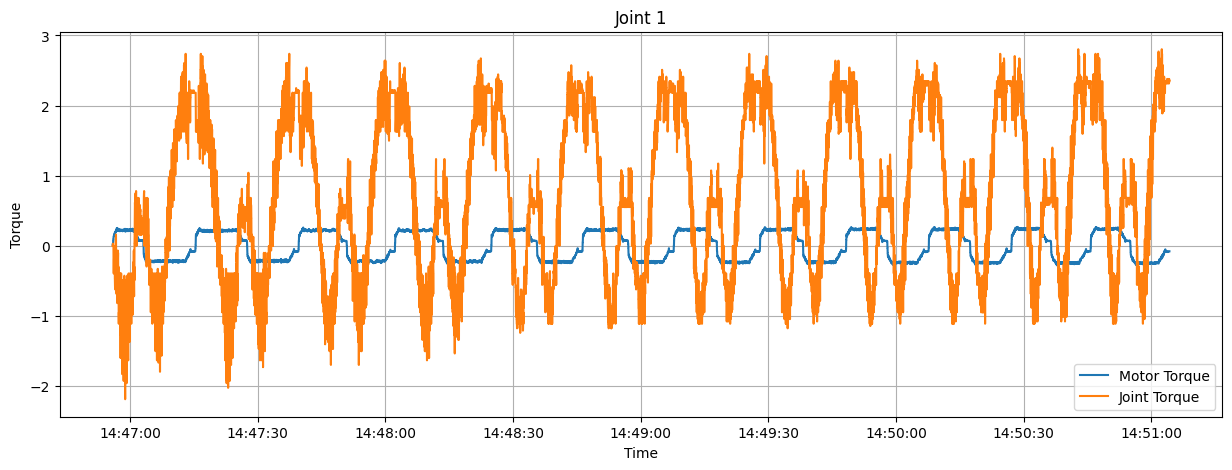

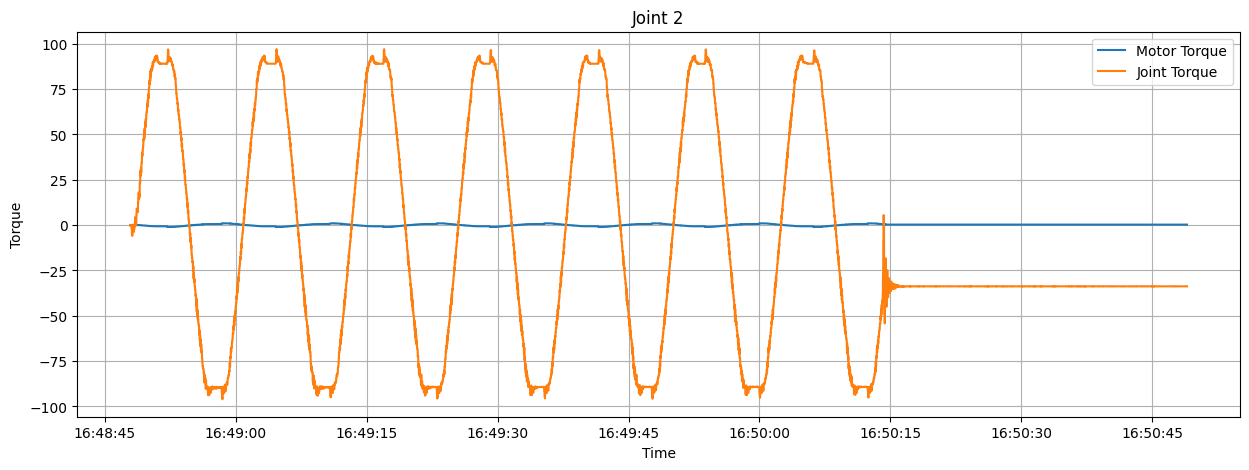

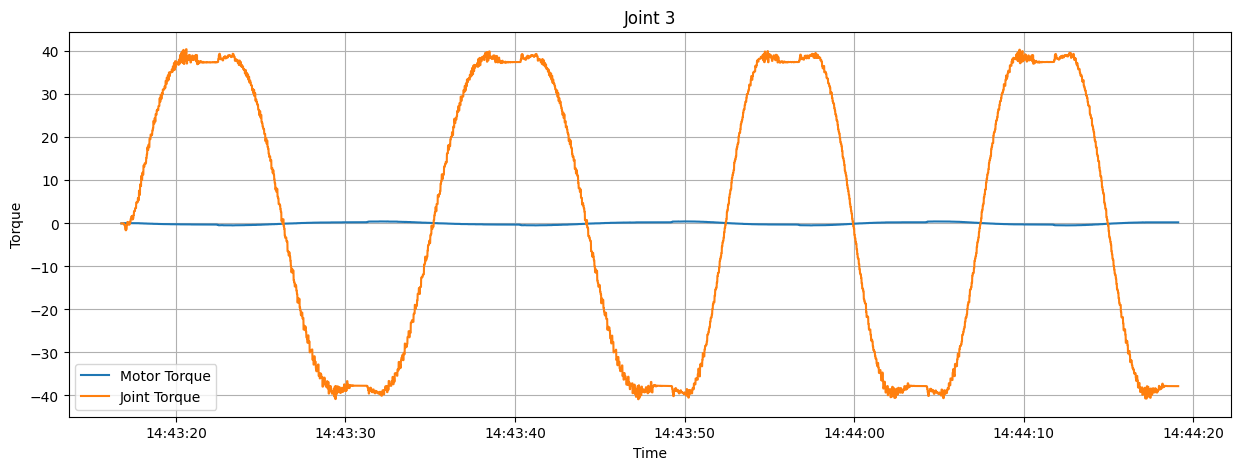

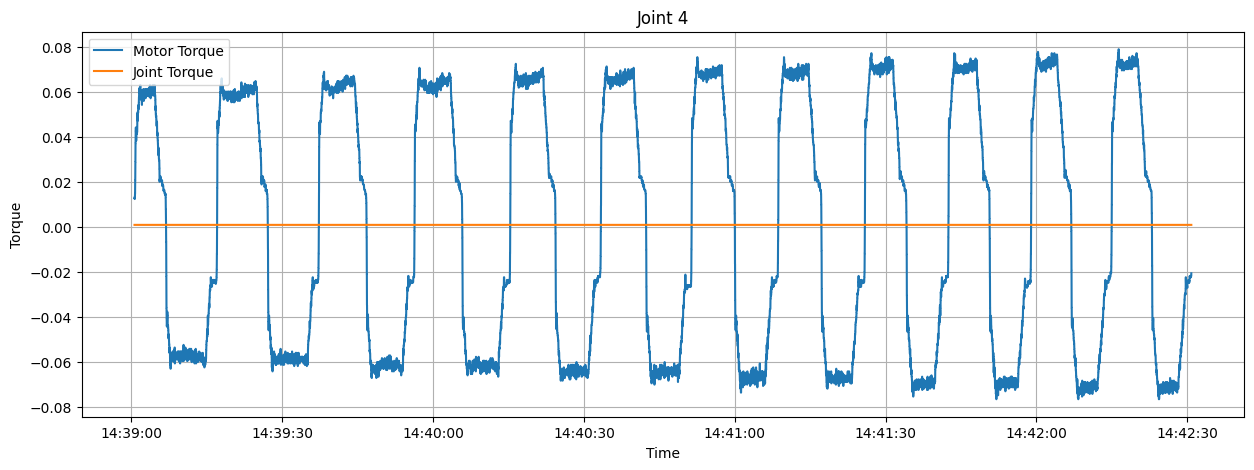

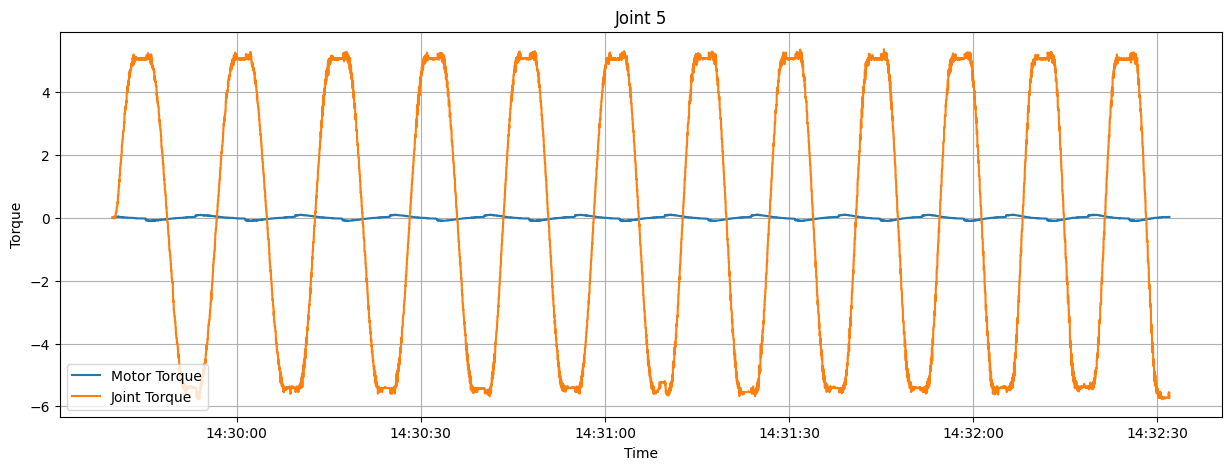

In [6]:
for joint_no, df in zip([1,2,3,4,5],[j1,j2,j3,j4,j5]):
    plt.figure(figsize=(15,5))

    plt.plot(
        df["timestamp"],
        df[f"m_t_{joint_no}"],
        label="Motor Torque"
    )

    plt.plot(
        df["timestamp"],
        df[f"jts{joint_no}"],
        label="Joint Torque"
    )

    plt.title(f"Joint {joint_no}")
    plt.xlabel("Time")
    plt.ylabel("Torque")
    plt.legend()
    plt.grid(True)
    plt.show()

# CONVERT TIME-STAMP TO SECONDS AND CALCULATE ACCELERATION

In [7]:
joint_data = {
    "J1": j1,
    "J2": j2,
    "J3": j3,
    "J4": j4,
    "J5": j5
}

for joint_name, df in joint_data.items():
    print(f"Processing {joint_name}...")

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S.%f")

    t0 = df["timestamp"].iloc[0]

    df["time_sec"] = (
        df["timestamp"] - t0
    ).dt.total_seconds()

    dt = df["time_sec"].diff()

    # Create all acceleration columns
    for i in range(1, 6):
        df[f"a{i}"] = (df[f"v{i}"].diff() / dt)
        df[f"a{i}"] = (df[f"a{i}"].fillna(0))

    # Desired acceleration order
    acc_cols = ["a1", "a2", "a3", "a4", "a5"]
    # Remaining columns
    other_cols = [ 
        col for col in df.columns
        if col not in acc_cols
    ]
    # Put acceleration columns at the end in order
    df = df[other_cols + acc_cols]
    
    save_file = (folder_path + f"\\{joint_name}_acceleration.csv")
    df.to_csv(save_file,index=False)
    print(f"Saved at -> {save_file}")

Processing J1...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J1_acceleration.csv
Processing J2...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J2_acceleration.csv
Processing J3...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J3_acceleration.csv
Processing J4...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J4_acceleration.csv
Processing J5...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J5_acceleration.csv


# IMPORT JOINT 1 AND DO EVERYTHING

## READING J1 DATA

In [8]:
df = pd.read_csv(
    folder_path +
    r"\J1_acceleration.csv"
)
print(df.shape)
df.head(10)

(49646, 31)


,timestamp,m_t_1,m_t_2,m_t_3,m_t_4,m_t_5,m_t_6,jts1,jts2,jts3,...,q3,q4,q5,q6,time_sec,a1,a2,a3,a4,a5
0,2026-06-05 14:46:55.892351,0.01830,-0.00732,-0.00000,0.00295,-0.00295,-0.00059,-0.002704,0.042514,0.013619,...,0.004807,-0.000000,0.002060,-0.002747,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,2026-06-05 14:46:55.897463,0.01830,-0.00732,-0.00000,0.00295,-0.00295,-0.00059,-0.002704,0.042514,0.013619,...,0.004807,-0.000000,0.002060,-0.002747,0.005112,0.000000,0.000000,0.000000,0.000000,0.0
2,2026-06-05 14:46:55.902346,0.01830,-0.00732,-0.00000,0.00295,-0.00295,-0.00059,-0.002704,0.042514,0.013619,...,0.004807,-0.000000,0.002060,-0.002747,0.009995,0.000000,0.000000,0.000000,0.000000,0.0
3,2026-06-05 14:46:55.907205,0.01830,-0.00732,-0.00000,0.00295,-0.00295,-0.00059,-0.002704,0.042514,0.013619,...,0.004807,-0.000000,0.002060,-0.002747,0.014854,0.000000,0.000000,0.000000,0.000000,0.0
4,2026-06-05 14:46:55.912472,0.01830,-0.00732,-0.00000,0.00295,-0.00295,-0.00059,-0.002704,0.042514,0.013619,...,0.004807,-0.000000,0.002060,-0.002747,0.020121,0.000000,0.000000,0.000000,0.000000,0.0
5,2026-06-05 14:46:55.917306,0.01830,-0.00732,-0.00000,0.00295,-0.00295,-0.00059,-0.002704,0.042514,0.013619,...,0.004807,-0.000000,0.002060,-0.002747,0.024955,0.000000,0.000000,0.000000,0.000000,0.0
6,2026-06-05 14:46:55.922352,0.01830,-0.00732,-0.00000,0.00295,-0.00295,-0.00059,-0.002704,0.042514,0.013619,...,0.004807,-0.000000,0.002060,-0.002747,0.030001,0.000000,0.000000,0.000000,0.000000,0.0
7,2026-06-05 14:46:55.927280,0.01647,-0.00915,-0.00107,0.00236,-0.00295,-0.00118,-0.002704,0.042514,0.002664,...,0.004807,0.001373,0.002747,-0.002747,0.034929,1.217532,-1.217532,45.048701,1.217532,0.0
8,2026-06-05 14:46:55.932335,0.01647,-0.00915,-0.00107,0.00236,-0.00295,-0.00118,-0.002704,0.042514,0.002664,...,0.004807,0.001373,0.002747,-0.002747,0.039984,0.000000,0.000000,0.000000,0.000000,0.0
9,2026-06-05 14:46:55.937293,0.01647,-0.00915,-0.00107,0.00236,-0.00295,-0.00118,-0.002704,0.042514,0.002664,...,0.004807,0.001373,0.002747,-0.002747,0.044942,0.000000,0.000000,0.000000,0.000000,0.0


# CONVERT FROM DEGREE TO RADIANS

In [9]:
df["q1"] = np.deg2rad(df["q1"])
df["v1"] = np.deg2rad(df["v1"])
df["a1"] = np.deg2rad(df["a1"])

# CHECKING MAX AND MIN RANGE

In [10]:
print(df["m_t_1"].min(), df["m_t_1"].max())
print(df["jts1"].min(), df["jts1"].max())
print(df["v1"].min(), df["v1"].max())
print(df["a1"].min(), df["a1"].max())

-0.27816 0.2690099999999999
-2.188373375484691 2.802837562015309
-0.7952418203786963 0.795974858664534
-5.916488460542405 7.245813564610246


## READ THE INPUT AND OUTPUT VARIABLES

In [ ]:
X = df[["q1", "v1", "a1", "m_t_1"]].values
y = df["jts1"].values.reshape(-1,1)

## SCALING

In [ ]:
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

In [13]:
y_actual = y

## TRAIN TEST SPLIT

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled, y_actual, test_size=0.2, random_state=42)

## TRAINABLE PHYSICS PARAMETERS

In [ ]:
N = 100.0

Jm_raw = tf.Variable(-8.0, trainable=True)
Bm_raw = tf.Variable(-8.0, trainable=True)
Tc_raw = tf.Variable(-3.0, trainable=True)
Bv_raw = tf.Variable(-5.0, trainable=True)
Vs_raw = tf.Variable(-3.0, trainable=True)

## RESIDUAL NETWORK

In [ ]:
inputs = Input(shape=(4,))

x = Dense(64, activation="relu")(inputs)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)

tau_corr = Dense(1)(x)

model = Model(inputs, tau_corr)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

## TENSOR CONVERSION

In [ ]:
X_train_tf = tf.constant(X_train, dtype=tf.float32)
y_train_tf = tf.constant(y_train, dtype=tf.float32)
X_test_tf = tf.constant(X_test, dtype=tf.float32)

## TRAINING LOOP

In [ ]:
optimizer = Adam(learning_rate=1e-3)
epochs = 3000
loss_history = []
mse_history = []
r2_history = []

In [ ]:
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        Jm = tf.nn.softplus(Jm_raw)
        Bm = tf.nn.softplus(Bm_raw)
        Tc = tf.nn.softplus(Tc_raw)
        Bv = tf.nn.softplus(Bv_raw)
        Vs = tf.nn.softplus(Vs_raw)

        tau_corr = model(X_train_tf, training=True)

        q = X_train_tf[:,0:1]
        v = X_train_tf[:,1:2]
        a = X_train_tf[:,2:3]
        tm = X_train_tf[:,3:4]

        tau_f = (Tc * tf.math.tanh(v / Vs) + Bv * v)

        tau_physics = (N * tm - N**2 * Jm * a - N**2 * Bm * v - tau_f)

        tau_pred = (tau_physics + tau_corr)

        data_loss = tf.reduce_mean(tf.square(tau_pred - y_train_tf))

        correction_loss = tf.reduce_mean(tf.square(tau_corr))

        total_loss = (data_loss + 0.001 * correction_loss)

    variables = (model.trainable_variables + [Jm_raw, Bm_raw, Tc_raw, Bv_raw, Vs_raw])

    grads = tape.gradient(total_loss, variables)

    optimizer.apply_gradients(zip(grads, variables))

    loss_history.append(total_loss.numpy())

    mse = mean_squared_error(y_train_tf.numpy(), tau_pred.numpy())
    r2 = r2_score(y_train_tf.numpy(), tau_pred.numpy())
    mse_history.append(mse)
    r2_history.append(r2)

    if epoch % 100 == 0:
        print("\nEpoch =", epoch)
        print("Loss =", total_loss.numpy())
        print("MSE =", mse)
        print("R2 =", r2)
        print("\nEstimated Parameters")
        print("Jm =", Jm.numpy())
        print("Bm =", Bm.numpy())
        print("Tc =", Tc.numpy())
        print("Bv =", Bv.numpy())
        print("Vs =", Vs.numpy())


Epoch = 0
Loss = 9349.172
MSE = 9349.1728515625
R2 = -7099.0263671875

Estimated Parameters
Jm = 0.00033540637
Bm = 0.00033540637
Tc = 0.048587352
Bv = 0.0067153485
Vs = 0.048587352

Epoch = 100
Loss = 1112.3809
MSE = 1107.8702392578125
R2 = -840.3479614257812

Estimated Parameters
Jm = 0.0003119878
Bm = 0.00036823846
Tc = 0.05321725
Bv = 0.007370324
Vs = 0.044925615

Epoch = 200
Loss = 38.643692
MSE = 29.410436630249023
R2 = -21.33511734008789

Estimated Parameters
Jm = 0.00030763552
Bm = 0.00037118056
Tc = 0.05366252
Bv = 0.007428992
Vs = 0.043977067

Epoch = 300
Loss = 31.480106
MSE = 22.23887062072754
R2 = -15.88882827758789

Estimated Parameters
Jm = 0.00030529164
Bm = 0.0003709352
Tc = 0.053680167
Bv = 0.007424106
Vs = 0.043622274

Epoch = 400
Loss = 26.925564
MSE = 17.679569244384766
R2 = -12.42636489868164

Estimated Parameters
Jm = 0.00030341226
Bm = 0.00037068204
Tc = 0.053704347
Bv = 0.0074190605
Vs = 0.043294672

Epoch = 500
Loss = 23.968166
MSE = 14.722128868103027
R2 = -

In [ ]:
Jm = tf.nn.softplus(Jm_raw)
Bm = tf.nn.softplus(Bm_raw)
Tc = tf.nn.softplus(Tc_raw)
Bv = tf.nn.softplus(Bv_raw)
Vs = tf.nn.softplus(Vs_raw)

tau_corr_test = model.predict(X_test_tf)

v = X_test_tf[:, 1:2]
a = X_test_tf[:, 2:3]
tm = X_test_tf[:, 3:4]

tau_f = (Tc * tf.math.tanh(v / Vs) + Bv * v)
tau_physics = (N * tm - N**2 * Jm * a - N**2 * Bm * v - tau_f)

tau_pred_test = (tau_physics.numpy() + tau_corr_test)

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step


In [ ]:
test_mse = mean_squared_error(y_test, tau_pred_test)
test_r2 = r2_score(y_test, tau_pred_test)
print("Test MSE =", test_mse)
print("Test R2 =", test_r2)

Test MSE = 0.3905374336641691
Test R2 = 0.7044659096875744


In [22]:
print("Jm =", Jm.numpy())
print("Bm =", Bm.numpy())
print("Tc =", Tc.numpy())
print("Bv =", Bv.numpy())
print("Vs =", Vs.numpy())

Jm = 0.00029394796
Bm = 0.0003787806
Tc = 0.054468375
Bv = 0.0075805057
Vs = 0.057067186


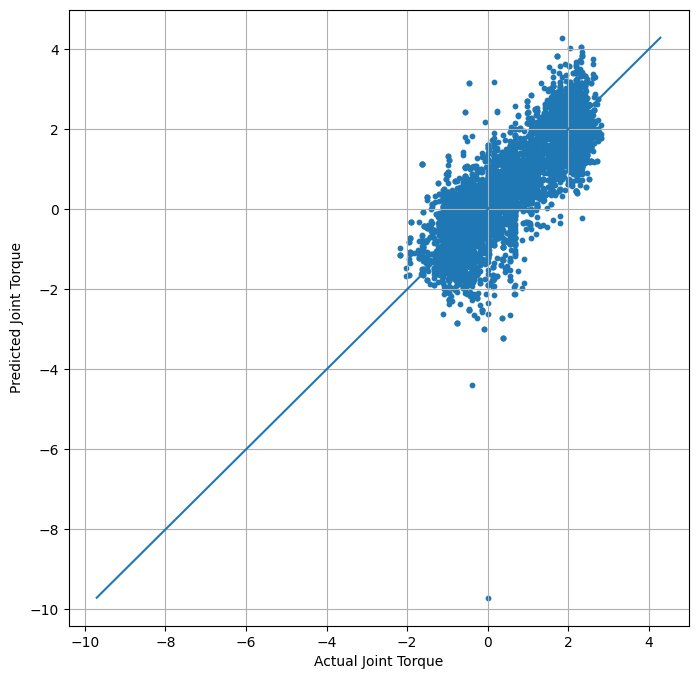

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, tau_pred_test, s=10)
mn = min(y_test.min(), tau_pred_test.min())
mx = max(y_test.max(), tau_pred_test.max())
plt.plot([mn,mx], [mn,mx])
plt.xlabel("Actual Joint Torque")
plt.ylabel("Predicted Joint Torque")
plt.grid(True)
plt.show()

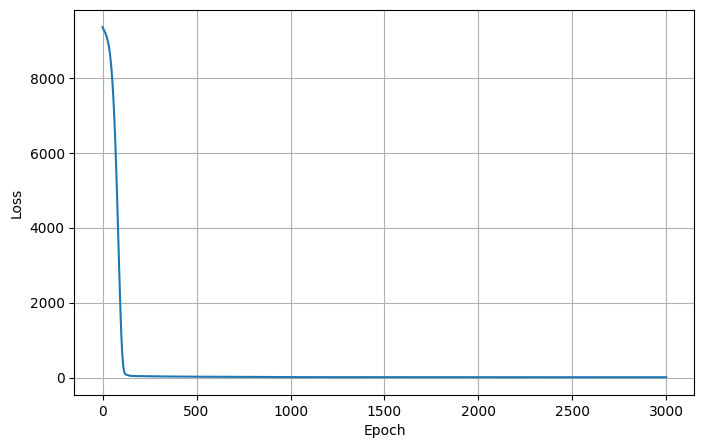

In [24]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [ ]:
X_test_tf = tf.constant(X_test, dtype=tf.float32)
tau_corr = model.predict(X_test_tf)
print(tau_corr[:10])

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step
[[-106.55766 ]
 [ 109.99985 ]
 [-114.72094 ]
 [ -37.83295 ]
 [-115.033264]
 [ 102.57945 ]
 [-102.54349 ]
 [-102.77219 ]
 [  97.678894]
 [ 107.272385]]


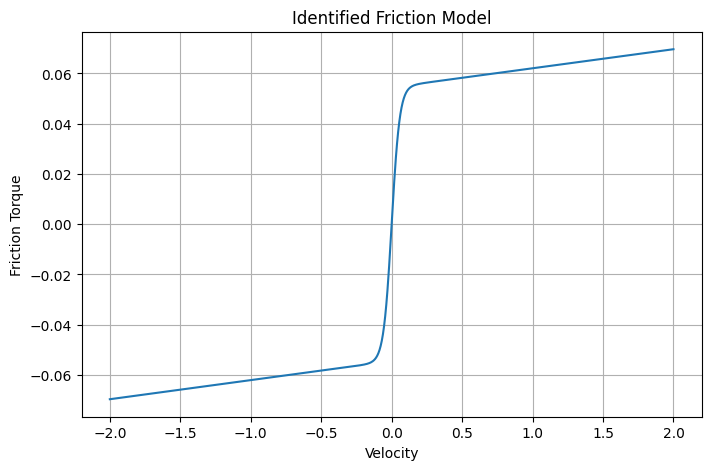

In [ ]:
v_range = np.linspace(-2, 2, 1000)
friction = (Tc.numpy() * np.tanh(v_range / Vs.numpy()) + Bv.numpy() * v_range)
plt.figure(figsize=(8,5))
plt.plot(v_range, friction)
plt.xlabel("Velocity")
plt.ylabel("Friction Torque")
plt.title("Identified Friction Model")
plt.grid()
plt.show()